# Import e set-up iniziale

In [59]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from pyvis.network import Network
import warnings

# Ignoriamo i warning sui dtypes misti per letture veloci
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

# Setup grafica
sns.set_theme(style="whitegrid")
print("✅ Librerie caricate con successo. Ambiente pronto.")

✅ Librerie caricate con successo. Ambiente pronto.


In [60]:
# ==========================================
# CONFIGURAZIONE GLOBALE - MODIFICA QUI
# ==========================================

# Soglie Statistiche
TARGET_GENE = 'KRAS'
P_VALUE_THRESH = 0.1    # Significatività statistica grezza
LOG2OR_THRESH = 1.0      # Forza dell'associazione (1.0 raddoppia le probabilità)

# Filtri Grafici (per Heatmap e Network)
MIN_COOCCURRENCE_NETWORK = 10  # Minimo pazienti comuni per disegnare un arco tra due geni partner
TOP_GENES_HEATMAP = 20         # Quanti geni mostrare nella heatmap iniziale

# Percorsi Cartelle
COORTI = {
    "pancreas": "./kras_pancreas",
    "lung": "./kras_lung",
    "colon": "./kras_colon"
}

print(f"⚙️ Parametri impostati: {TARGET_GENE} con FDR < {FDR_THRESH} e Log2OR > {LOG2OR_THRESH}")

⚙️ Parametri impostati: KRAS con FDR < 0.0 e Log2OR > 1.0


# Filtri

In [61]:
# ==========================================
# CELLA 2: FILTRO PAZIENTI SULLE MUTAZIONI
# ==========================================
def filter_samples_by_id(reference_filename, target_files_list, folder_path, output_prefix="F_"):
    reference_csv_path = os.path.join(folder_path, reference_filename)
    
    try:
        ref_df = pd.read_csv(reference_csv_path, sep='\t')
        valid_ids = set(ref_df['Sample_Id'].astype(str).unique())
        print(f"\n--- {folder_path.upper()} ---")
        print(f"[*] ID validi nel master: {len(valid_ids)}")
    except Exception as e:
        print(f"[!] Errore master {reference_csv_path}: {e}")
        return

    for filename in target_files_list:
        file_input_path = os.path.join(folder_path, filename)
        if not os.path.exists(file_input_path): continue
            
        target_df = pd.read_csv(file_input_path, sep='\t')
        
        if 'Sample_Id' in target_df.columns:
            filtered_df = target_df[target_df['Sample_Id'].astype(str).isin(valid_ids)]
            output_full_path = os.path.join(folder_path, f"{output_prefix}{filename}")
            filtered_df.to_csv(output_full_path, index=False, sep='\t')
            print(f"[*] Mutazioni filtrate salvate: {output_full_path} ({len(filtered_df)} righe)")

file_da_filtrare = ["data_mutations.txt"] 
filter_samples_by_id('F_nokras_pancreas.csv', file_da_filtrare, "./kras_pancreas/")
filter_samples_by_id('F_nokras_lung.csv', file_da_filtrare, "./kras_lung/")
filter_samples_by_id('F_nokras_colon.csv', file_da_filtrare, "./kras_colon/")


--- ./KRAS_PANCREAS/ ---
[*] ID validi nel master: 1672
[*] Mutazioni filtrate salvate: ./kras_pancreas/F_data_mutations.txt (7115 righe)

--- ./KRAS_LUNG/ ---
[*] ID validi nel master: 3833
[*] Mutazioni filtrate salvate: ./kras_lung/F_data_mutations.txt (33990 righe)

--- ./KRAS_COLON/ ---
[*] ID validi nel master: 2347
[*] Mutazioni filtrate salvate: ./kras_colon/F_data_mutations.txt (41821 righe)


In [62]:
# ==========================================
# CELLA 3: FILTRO DATI CNA (COPY NUMBER)
# ==========================================
def filter_columns_by_master(path, master_path, target_path, output_path):
    if not os.path.exists(f"{path}/{master_path}"): return

    master_df = pd.read_csv(f"{path}/{master_path}", sep='\t')
    valid_ids = set(master_df['Sample_Id'].astype(str).unique())

    target_df = pd.read_csv(f"{path}/{target_path}", sep='\t')
    
    columns_to_keep = [col for col in target_df.columns if col == 'Hugo_Symbol' or col in valid_ids]
    filtered_df = target_df[columns_to_keep]
    
    filtered_df.to_csv(f"{path}/{output_path}", sep='\t', index=False)
    print(f"[*] CNA filtrato per {path}. Colonne salvate: {len(columns_to_keep)}")

filter_columns_by_master("./kras_pancreas", 'F_nokras_pancreas.csv', 'data_cna.txt', 'F_data_cna.txt')
filter_columns_by_master("./kras_lung", 'F_nokras_lung.csv', 'data_cna.txt', 'F_data_cna.txt')
filter_columns_by_master("./kras_colon", 'F_nokras_colon.csv', 'data_cna.txt', 'F_data_cna.txt')

[*] CNA filtrato per ./kras_pancreas. Colonne salvate: 1670
[*] CNA filtrato per ./kras_lung. Colonne salvate: 3834
[*] CNA filtrato per ./kras_colon. Colonne salvate: 2347


# Matrici di Co-Occorrenza

In [63]:
# ==========================================
# CELLA 4: MATRICI BINARIE E HEATMAP (CON LOG)
# ==========================================
def generate_cooccurrence_data(filtered_mutations_file, cohort_name, output_dir, target_gene=TARGET_GENE):
    if not os.path.exists(filtered_mutations_file): 
        print(f"[!] File non trovato: {filtered_mutations_file}")
        return None
        
    df = pd.read_csv(filtered_mutations_file, sep='\t')
    
    # Filtro Health Lab
    functional_variants = [
        'Missense_Mutation', 'Nonsense_Mutation', 'Frame_Shift_Del', 
        'Frame_Shift_Ins', 'In_Frame_Del', 'In_Frame_Ins', 'Splice_Site', 
        'Translation_Start_Site', 'Nonstop_Mutation'
    ]
    df_func = df[df['Variant_Classification'].isin(functional_variants)].copy()
    
    # LOG DI CONTROLLO BIOLOGICO
    print(f"\n--- 📊 ANALISI DATI: {cohort_name.upper()} ---")
    print(f"[*] Righe totali nel file mutazioni: {len(df)}")
    print(f"[*] Mutazioni funzionali (Health Lab): {len(df_func)}")
    print(f"[*] Rumore rimosso (Silenti/Introniche): {len(df) - len(df_func)}")

    if df_func.empty: 
        print("[!] Attenzione: Nessuna mutazione funzionale trovata!")
        return None

    # Creazione matrice
    pat_gene_counts = pd.crosstab(df_func['Sample_Id'], df_func['Hugo_Symbol'])
    binary_matrix = (pat_gene_counts > 0).astype(int)
    
    # BUG FIX: Reintegra pazienti Wild-Type
    tutti_i_pazienti = df['Sample_Id'].unique() 
    binary_matrix = binary_matrix.reindex(tutti_i_pazienti, fill_value=0)
    
    print(f"[*] Dimensioni Matrice: {binary_matrix.shape[0]} pazienti x {binary_matrix.shape[1]} geni")
    
    # Salvataggio
    os.makedirs(output_dir, exist_ok=True)
    binary_matrix.to_csv(os.path.join(output_dir, f"M_binary_pat_gene_{cohort_name}.csv"), sep='\t')
    
    co_occ_matrix = binary_matrix.T.dot(binary_matrix)
    co_occ_matrix.to_csv(os.path.join(output_dir, f"M_cooccurrence_gene_gene_{cohort_name}.tsv"), sep='\t')

    # Heatmap
    top_genes = binary_matrix.sum().sort_values(ascending=False).index[:TOP_GENES_HEATMAP]
    subset_matrix = co_occ_matrix.loc[top_genes, top_genes]
    mask = np.triu(np.ones_like(subset_matrix, dtype=bool), k=1)

    plt.figure(figsize=(10, 8))
    sns.heatmap(subset_matrix, mask=mask, cmap="YlOrRd", annot=True, fmt='d')
    plt.title(f"Co-occorrenze {cohort_name.upper()} (Top {TOP_GENES_HEATMAP} geni)")
    plt.savefig(os.path.join(output_dir, f"Heatmap_{cohort_name}.png"))
    plt.close()
    
    print(f"✅ Matrici e Heatmap salvate in: {output_dir}")

# Esecuzione
for name, path in COORTI.items():
    generate_cooccurrence_data(f"{path}/F_data_mutations.txt", name, f"{path}/co_occurr_output")


--- 📊 ANALISI DATI: PANCREAS ---
[*] Righe totali nel file mutazioni: 7115
[*] Mutazioni funzionali (Health Lab): 7105
[*] Rumore rimosso (Silenti/Introniche): 10
[*] Dimensioni Matrice: 1606 pazienti x 463 geni
✅ Matrici e Heatmap salvate in: ./kras_pancreas/co_occurr_output

--- 📊 ANALISI DATI: LUNG ---
[*] Righe totali nel file mutazioni: 33990
[*] Mutazioni funzionali (Health Lab): 33734
[*] Rumore rimosso (Silenti/Introniche): 256
[*] Dimensioni Matrice: 3658 pazienti x 513 geni
✅ Matrici e Heatmap salvate in: ./kras_lung/co_occurr_output

--- 📊 ANALISI DATI: COLON ---
[*] Righe totali nel file mutazioni: 41821
[*] Mutazioni funzionali (Health Lab): 41679
[*] Rumore rimosso (Silenti/Introniche): 142
[*] Dimensioni Matrice: 2335 pazienti x 513 geni
✅ Matrici e Heatmap salvate in: ./kras_colon/co_occurr_output


# Analisi Statistica

In [64]:
# ==========================================
# CELLA 5: ANALISI STATISTICA (VERSIONE P-VALUE GREZZO)
# ==========================================
def analyze_significance(binary_matrix_file, output_path, target_gene, p_threshold):
    """
    Esegue il Test di Fisher per valutare la co-occorrenza.
    Non applica la correzione FDR (Benjamini-Hochberg).
    """
    if not os.path.exists(binary_matrix_file): 
        print(f"[!] File non trovato: {binary_matrix_file}")
        return None
        
    # Caricamento matrice binaria
    df_bin = pd.read_csv(binary_matrix_file, sep='\t', index_col=0).fillna(0)
    
    if target_gene not in df_bin.columns: 
        print(f"[!] {target_gene} non trovato nella matrice.")
        return None

    genes = [g for g in df_bin.columns if g != target_gene]
    results = []

    # Calcolo statistico per ogni gene partner
    for gene_x in genes:
        # Conteggi per la tabella di contingenza
        a = ((df_bin[target_gene] == 1) & (df_bin[gene_x] == 1)).sum()
        b = ((df_bin[target_gene] == 1) & (df_bin[gene_x] == 0)).sum()
        c = ((df_bin[target_gene] == 0) & (df_bin[gene_x] == 1)).sum()
        d = ((df_bin[target_gene] == 0) & (df_bin[gene_x] == 0)).sum()

        table = [[a, b], [c, d]]
        
        # Test Esatto di Fisher (unilaterale destro per co-occorrenza)
        odds_ratio, p_value = fisher_exact(table, alternative='greater')
        
        # Calcolo Log2 Odds Ratio (forza dell'effetto)
        log2or = np.log2(odds_ratio) if odds_ratio > 0 else -np.inf

        results.append({
            'Gene_B': gene_x, 
            'Co_Occurrence_Count': a, 
            'P_Value': p_value, 
            'Log2OR': log2or
        })

    results_df = pd.DataFrame(results)

    # LOG DEI RISULTATI
    print(f"\n--- 🔬 STATISTICHE COMPLETATE: {os.path.basename(binary_matrix_file)} ---")
    
    # Filtriamo i geni significativi basandoci sulla variabile globale P_VALUE_THRESH
    sig_genes = results_df[results_df['P_Value'] <= p_threshold].sort_values(by='P_Value')
    
    print(f"[*] Soglia P-Value utilizzata: {p_threshold}")
    print(f"[*] Geni significativi trovati: {len(sig_genes)}")
    
    if not sig_genes.empty:
        print("[*] Prime 10 associazioni per P-Value:")
        # Mostriamo i primi 10 per avere un'idea chiara durante l'esecuzione
        print(sig_genes[['Gene_B', 'Co_Occurrence_Count', 'Log2OR', 'P_Value']].head(10).to_string(index=False))

    # Salvataggio su file
    results_df.to_csv(output_path, sep='\t', index=False)
    print(f"✅ Risultati salvati in: {output_path}")
    
    return results_df

# ==========================================
# ESECUZIONE
# ==========================================
dfs_risultati = {}

for name in COORTI.keys():
    bin_file = f"./kras_{name}/co_occurr_output/M_binary_pat_gene_{name}.csv"
    out_file = f"./kras_{name}/co_occurr_output/Stat_Results_{name}.csv"
    
    # Passiamo TARGET_GENE e P_VALUE_THRESH definiti nella Cella 0
    dfs_risultati[name] = analyze_significance(
        binary_matrix_file=bin_file, 
        output_path=out_file, 
        target_gene=TARGET_GENE, 
        p_threshold=P_VALUE_THRESH
    )


--- 🔬 STATISTICHE COMPLETATE: M_binary_pat_gene_pancreas.csv ---
[*] Soglia P-Value utilizzata: 0.1
[*] Geni significativi trovati: 10
[*] Prime 10 associazioni per P-Value:
Gene_B  Co_Occurrence_Count   Log2OR      P_Value
  TP53                 1103 3.299862 3.405226e-47
CDKN2A                  345 1.595512 2.638295e-07
 SMAD4                  314 1.264753 3.434225e-05
 KDM6A                   65 2.303999 5.451005e-03
TGFBR2                   63 1.664667 2.230037e-02
 SMAD3                   27      inf 2.424628e-02
 RNF43                   94 1.024547 4.114139e-02
 SF3B1                   30 2.158303 7.829504e-02
 U2AF1                   30 2.158303 7.829504e-02
 FBXW7                   17      inf 9.690649e-02
✅ Risultati salvati in: ./kras_pancreas/co_occurr_output/Stat_Results_pancreas.csv

--- 🔬 STATISTICHE COMPLETATE: M_binary_pat_gene_lung.csv ---
[*] Soglia P-Value utilizzata: 0.1
[*] Geni significativi trovati: 40
[*] Prime 10 associazioni per P-Value:
Gene_B  Co_Occurrence

# Plot

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/transforms.py:352: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


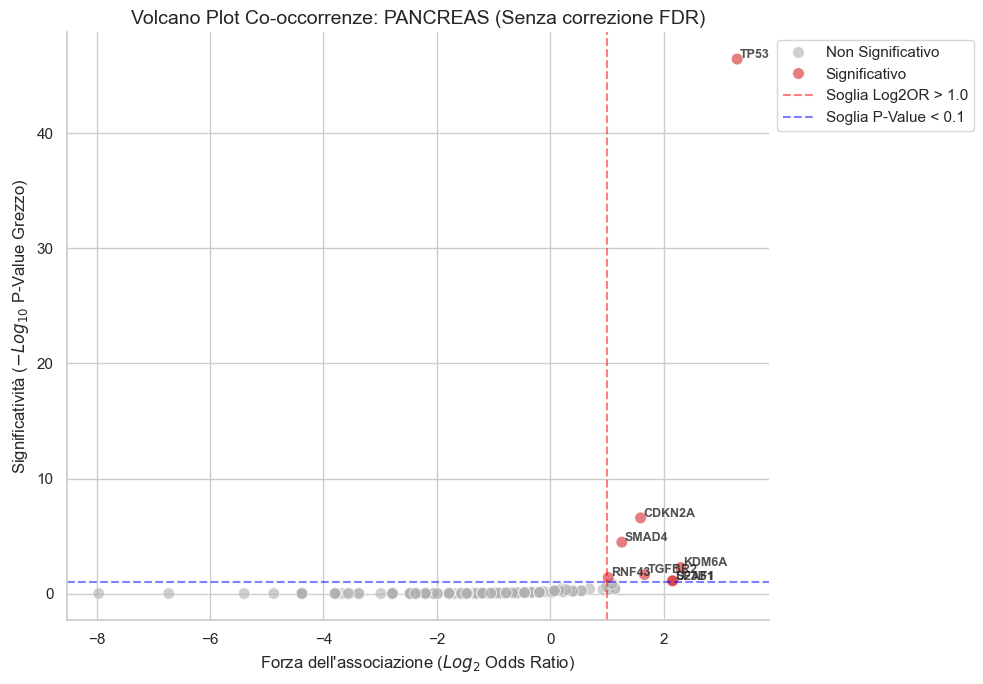


--- 📈 VISUALIZZAZIONE: PANCREAS ---
[*] Geni totali mappati: 462
[*] Geni sopra la soglia di significatività: 10


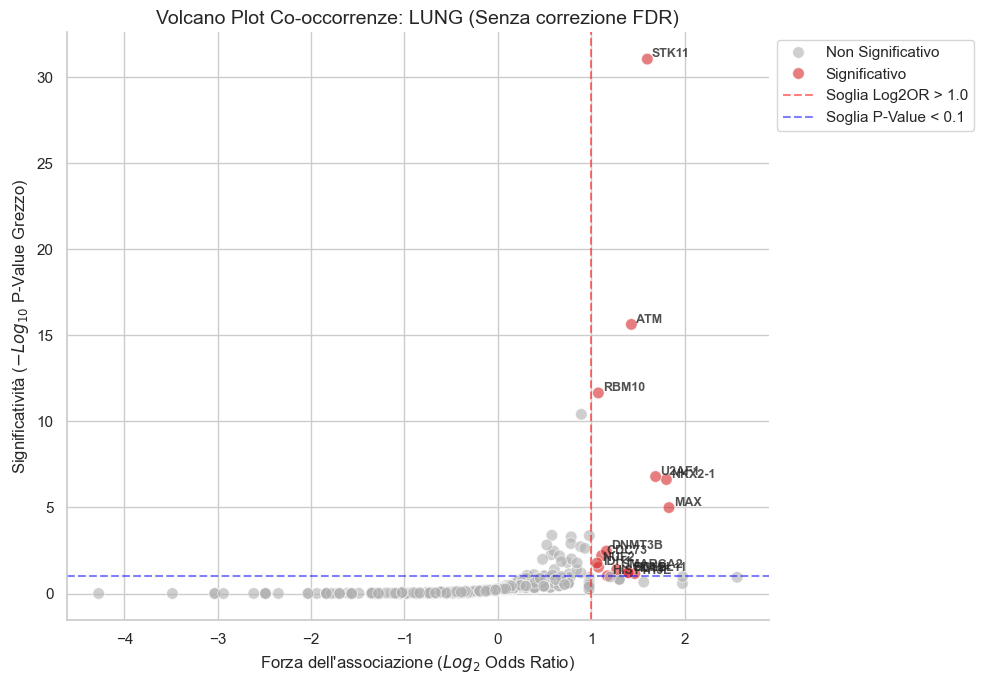


--- 📈 VISUALIZZAZIONE: LUNG ---
[*] Geni totali mappati: 512
[*] Geni sopra la soglia di significatività: 15


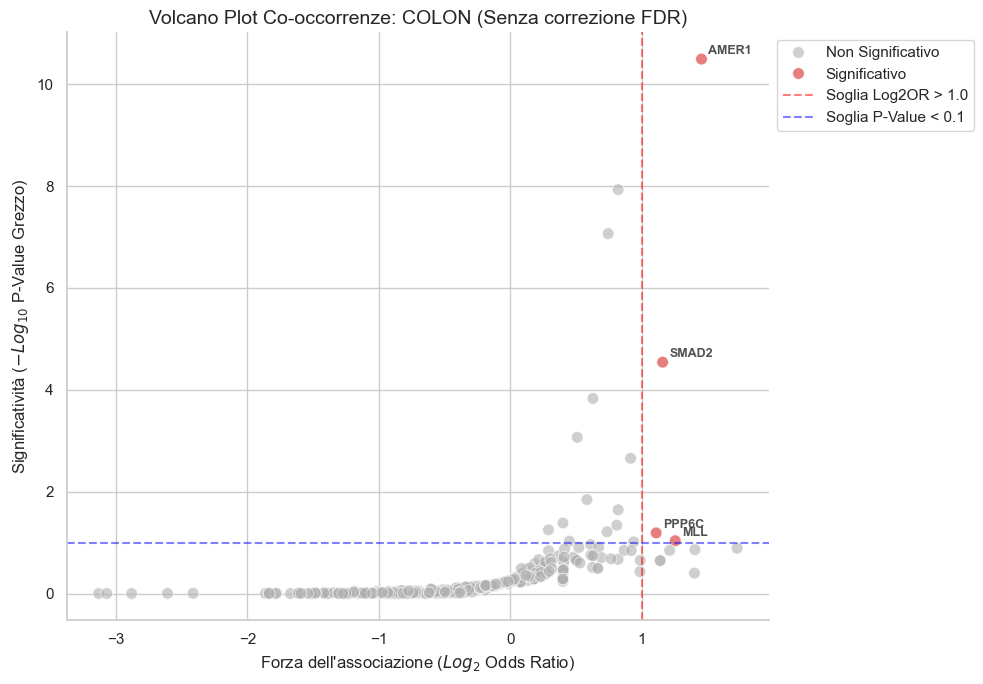


--- 📈 VISUALIZZAZIONE: COLON ---
[*] Geni totali mappati: 512
[*] Geni sopra la soglia di significatività: 4


In [65]:
# ==========================================
# CELLA 6: VOLCANO PLOT (VERSIONE P-VALUE GREZZO)
# ==========================================
def plot_volcano(df_results, cohort_name, log2or_thresh, p_thresh):
    """
    Genera un Volcano Plot basato sul P-Value grezzo.
    Asse X: Log2 Odds Ratio (Forza dell'associazione)
    Asse Y: -Log10 P-Value (Significatività statistica)
    """
    if df_results is None or df_results.empty:
        print(f"[!] Dati insufficienti per il Volcano Plot di {cohort_name}")
        return
    
    df_plot = df_results.copy()
    
    # Trasformazione Logaritmica dell'asse Y (P-Value grezzo)
    # Usiamo 1e-300 per evitare errori matematici con p-value pari a 0
    df_plot['neg_log10_p'] = -np.log10(df_plot['P_Value'] + 1e-300)
    
    # Definizione dello stato in base alle variabili globali
    cond_sig = (df_plot['Log2OR'] >= log2or_thresh) & (df_plot['P_Value'] <= p_thresh)
    df_plot['Stato'] = np.where(cond_sig, 'Significativo', 'Non Significativo')
    
    # Setup del grafico
    plt.figure(figsize=(10, 7))
    
    # Plot dei punti
    scatter = sns.scatterplot(
        data=df_plot, 
        x='Log2OR', 
        y='neg_log10_p', 
        hue='Stato',
        palette={'Significativo': '#d62728', 'Non Significativo': '#b0b0b0'},
        alpha=0.6,
        s=70,
        edgecolor='w'
    )
    
    # Linee tratteggiate per le soglie impostate nella Cella 0
    plt.axvline(x=log2or_thresh, color='red', linestyle='--', alpha=0.5, label=f'Soglia Log2OR > {log2or_thresh}')
    plt.axhline(y=-np.log10(p_thresh), color='blue', linestyle='--', alpha=0.5, label=f'Soglia P-Value < {p_thresh}')
    
    # Annotazione dei geni significativi (solo quelli che superano entrambe le soglie)
    sig_list = df_plot[cond_sig]
    for _, row in sig_list.iterrows():
        plt.text(
            row['Log2OR'] + 0.05, 
            row['neg_log10_p'] + 0.1, 
            row['Gene_B'], 
            fontsize=9, 
            weight='bold',
            alpha=0.8
        )
        
    # Personalizzazione etichette e titoli
    plt.title(f'Volcano Plot Co-occorrenze: {cohort_name.upper()} (Senza correzione FDR)', fontsize=14)
    plt.xlabel('Forza dell\'associazione ($Log_2$ Odds Ratio)', fontsize=12)
    plt.ylabel('Significatività ($-Log_{10}$ P-Value Grezzo)', fontsize=12)
    
    # Posizionamento legenda
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    sns.despine()
    plt.tight_layout()
    plt.show()

    # LOG DI DETTAGLIO
    print(f"\n--- 📈 VISUALIZZAZIONE: {cohort_name.upper()} ---")
    print(f"[*] Geni totali mappati: {len(df_plot)}")
    print(f"[*] Geni sopra la soglia di significatività: {cond_sig.sum()}")

# ==========================================
# ESECUZIONE
# ==========================================
for name, df in dfs_risultati.items():
    # Utilizza le variabili globali LOG2OR_THRESH e P_VALUE_THRESH definite nella Cella 0
    plot_volcano(df, name, log2or_thresh=LOG2OR_THRESH, p_thresh=P_VALUE_THRESH)

# Visualizzazione Network

In [66]:
# ==========================================
# CELLA 7: NETWORK INTERATTIVA (FIX OVERFLOW)
# ==========================================
def build_interactive_significant_network(stat_file, mat_file, output_dir, cohort_name, target_gene=TARGET_GENE):
    if not os.path.exists(stat_file) or not os.path.exists(mat_file):
        print(f"[!] File necessari non trovati per {cohort_name}.")
        return None

    # 1. Carica i risultati e filtra
    df_stats = pd.read_csv(stat_file, sep='\t')
    df_sig = df_stats[(df_stats['Log2OR'] >= LOG2OR_THRESH) & (df_stats['P_Value'] <= P_VALUE_THRESH)].copy()

    if df_sig.empty:
        print(f"[-] {cohort_name.upper()}: Nessun gene supera le soglie per la rete.")
        return None

    coocc_matrix = pd.read_csv(mat_file, sep='\t', index_col=0)
    G = nx.Graph()
    G.add_node(target_gene, size=40, color='#d62728', title=f"TARGET: {target_gene}", font={'size': 20})

    # 4. Aggiungi i nodi e gli archi verso il target
    for _, row in df_sig.iterrows():
        gene_b = row['Gene_B']
        
        # --- FIX PROTEZIONE INFINITO ---
        log_val = row['Log2OR']
        # Se Log2OR è infinito, lo blocchiamo a un valore massimo (es. 10) per il calcolo grafico
        if np.isinf(log_val):
            log_val = 10.0 
        
        node_size = float(15 + (log_val * 8))
        # -------------------------------

        weight = int(row['Co_Occurrence_Count'])
        p_val = float(row['P_Value'])
        
        tooltip = f"Gene: {gene_b}<br>Log2OR: {row['Log2OR']:.2f}<br>P-Value: {p_val:.4e}<br>Co-occorrenze: {weight}"
        
        G.add_node(gene_b, size=node_size, color='#1f77b4', title=tooltip)
        G.add_edge(target_gene, gene_b, weight=weight, value=weight, color='#999999')

        # 5. Archi secondari tra i partner
        for other_gene in df_sig['Gene_B']:
            if gene_b != other_gene and gene_b in coocc_matrix.index and other_gene in coocc_matrix.columns:
                edge_weight = int(coocc_matrix.loc[gene_b, other_gene])
                if edge_weight > MIN_COOCCURRENCE_NETWORK:
                    G.add_edge(gene_b, other_gene, weight=edge_weight, value=edge_weight, color='#e0e0e0', alpha=0.5)

    # 6. Configurazione PyVis
    net = Network(notebook=True, cdn_resources='remote', height="700px", width="100%", bgcolor="#ffffff")
    net.from_nx(G)
    net.repulsion(node_distance=200)

    os.makedirs(output_dir, exist_ok=True)
    html_path = os.path.join(output_dir, f"Network_{cohort_name}.html")
    net.show(html_path)
    
    print(f"\n--- 🌐 NETWORK GENERATA: {cohort_name.upper()} ---")
    print(f"[*] Nodi totali: {G.number_of_nodes()}")
    print(f"✅ Rete salvata in: {html_path}")
    return G

# Esecuzione
for name in COORTI.keys():
    build_interactive_significant_network(
        f"./kras_{name}/co_occurr_output/Stat_Results_{name}.csv",
        f"./kras_{name}/co_occurr_output/M_cooccurrence_gene_gene_{name}.tsv",
        f"./kras_{name}/networks/",
        name
    )

./kras_pancreas/networks/Network_pancreas.html

--- 🌐 NETWORK GENERATA: PANCREAS ---
[*] Nodi totali: 11
✅ Rete salvata in: ./kras_pancreas/networks/Network_pancreas.html
./kras_lung/networks/Network_lung.html

--- 🌐 NETWORK GENERATA: LUNG ---
[*] Nodi totali: 16
✅ Rete salvata in: ./kras_lung/networks/Network_lung.html
./kras_colon/networks/Network_colon.html

--- 🌐 NETWORK GENERATA: COLON ---
[*] Nodi totali: 5
✅ Rete salvata in: ./kras_colon/networks/Network_colon.html
